# Phase 3 - Hyperparameter Optimization

In [20]:
# Public Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import sys
from sklearn.model_selection import train_test_split
import optuna
from optuna.trial import TrialState
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Custom Imports
src_dir = Path("../src")
sys.path.insert(0, str(src_dir))

from evaluate import *
from model import *
# from train import *

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create models directory if it doesn't exist
models_dir = Path("../models")

## Load Training and Test Data

### Via np export (Comment out if not used)

In [21]:
# Define paths for data and models
data_dir = Path("../data/processed")

X_train_path = data_dir / "X_train.npy"
X_test_path = data_dir / "X_test.npy"
y_train_path = data_dir / "y_train.npy"
y_test_path = data_dir / "y_test.npy"

# Load the data
X_train = np.load(X_train_path)
X_test = np.load(X_test_path)
y_train = np.load(y_train_path)
y_test = np.load(y_test_path)

# Display the first 5 rows of the training and testing sets
# print("Train X Set:")
# display(X_train[:1])

# print("Train y Set:")
# display(y_train[:5])

# print("Test X Set:")
# display(X_test[:1])

# print("Test y Set:")
# display(y_test[:5])


# Print the shapes and data types of the training and testing sets
print("Data Summary:")
print("X_train shape:", X_train.shape)
print("X_test shapen:", X_test.shape)
print("\nX_train dtype:", X_train.dtype)
print("X_test dtype:", X_test.dtype)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining labels:")
print(np.unique(y_train, return_counts=True))
print("Testing labels:")
print(np.unique(y_test, return_counts=True))


# Split the training data into a fitting set and a validation set 
print("\nSplitting training data into fitting and validation sets...")
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training set for fitting:   {X_train.shape}")
print(f"Validation set for tuning: {X_val.shape}")
print(f"Test set (held-out):       {X_test.shape}")

Data Summary:
X_train shape: (61482, 118)
X_test shapen: (84104, 118)

X_train dtype: float32
X_test dtype: float32

y_train shape: (61482,)
y_test shape: (84104,)

Training labels:
(array([0]), array([61482]))
Testing labels:
(array([0, 1]), array([26350, 57754]))

Splitting training data into fitting and validation sets...
Training set for fitting:   (61482, 118)
Validation set for tuning: (12297, 118)
Test set (held-out):       (84104, 118)


## Hyperparameter Grid Setup (3.1)

In [22]:
# Enhanced hyperparameter search space
search_space = {
    'latent_dim': [8, 16, 32, 64, 128],
    'learning_rate': [1e-2, 5e-3, 1e-3, 5e-4, 1e-4],  # Logarithmic spacing
    'batch_size': [32, 64, 128, 256],  # Added 256 to match baseline
    'dropout_rate': [0.0, 0.1, 0.2, 0.3],
    'n_hidden_layers': [1, 2, 3],
    'hidden_units': [16, 32, 64, 128],  # Direct specification instead of geometric
    'activation': ['relu', 'tanh', 'sigmoid']  # Activation function exploration
}

# Output the search space for verification
print("\nHyperparameter Search Space:")
for param, values in search_space.items():
    print(f"{param}: {values}")


Hyperparameter Search Space:
latent_dim: [8, 16, 32, 64, 128]
learning_rate: [0.01, 0.005, 0.001, 0.0005, 0.0001]
batch_size: [32, 64, 128, 256]
dropout_rate: [0.0, 0.1, 0.2, 0.3]
n_hidden_layers: [1, 2, 3]
hidden_units: [16, 32, 64, 128]
activation: ['relu', 'tanh', 'sigmoid']


## Model Tuning & Architecture Testing (3.2)

In [23]:
# Develop functions here (Finsihed function go into the .py files in the src folder)
def build_autoencoder(input_dim, latent_dim, dropout_rate=0.0, n_hidden_layers=1, 
                     hidden_units=32, activation='relu'):
    """
    Build a symmetric (undercomplete) autoencoder with flexible architecture.
    
    Parameters:
    - input_dim: Input feature dimension
    - latent_dim: Bottleneck dimension
    - dropout_rate: Dropout rate (0.0 = disabled)
    - n_hidden_layers: Number of hidden layers per side (encoder/decoder)
    - hidden_units: Number of units in each hidden layer
    - activation: Activation function to use
    """
    model = Sequential(
        name=f"autoencoder_ld{latent_dim}_L{n_hidden_layers}_do{dropout_rate}_hu{hidden_units}_{activation}"
    )
    model.add(layers.Input(shape=(input_dim,)))

    # Encoder
    for _ in range(n_hidden_layers):
        model.add(layers.Dense(hidden_units, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(latent_dim, activation=activation, name="bottleneck"))

    # Decoder (mirror of encoder)
    for _ in range(n_hidden_layers):
        model.add(layers.Dense(hidden_units, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(input_dim, activation='linear'))  # Linear output for reconstruction

    return model


def objective(trial):
    # Sample hyperparameters
    config = {
        'latent_dim': trial.suggest_categorical('latent_dim', search_space['latent_dim']),
        'learning_rate': trial.suggest_categorical('learning_rate', search_space['learning_rate']),
        'batch_size': trial.suggest_categorical('batch_size', search_space['batch_size']),
        'dropout_rate': trial.suggest_categorical('dropout_rate', search_space['dropout_rate']),
        'n_hidden_layers': trial.suggest_categorical('n_hidden_layers', search_space['n_hidden_layers']),
        'hidden_units': trial.suggest_categorical('hidden_units', search_space['hidden_units']),
        'activation': trial.suggest_categorical('activation', search_space['activation'])
    }
    
    # Build and train model
    model = build_autoencoder(
        input_dim=INPUT_DIM,
        latent_dim=config['latent_dim'],
        dropout_rate=config['dropout_rate'],
        n_hidden_layers=config['n_hidden_layers'],
        hidden_units=config['hidden_units'],
        activation=config['activation']
    )
    
    model.compile(optimizer=Adam(learning_rate=config['learning_rate']), loss='mse')
    
    # Use early stopping with reasonable patience
    early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    
    history = model.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=30,  # Reduced epochs during search
        batch_size=config['batch_size'],
        callbacks=[early_stop],
        verbose=0,
    )
    
    val_loss = float(min(history.history['val_loss']))
    return val_loss

In [ ]:
# Test code cells here
INPUT_DIM = X_train.shape[1]

# Create study and optimize
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=1800)  # 30 minute timeout

# Get best parameters
best_config = study.best_params
best_val_loss = study.best_value

print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Best config: {best_config}")

# Save results
results_df = study.trials_dataframe()
results_df.to_csv(models_dir / "hyperparam_search_results_v2.csv", index=False)

# Train final model with best config on full training data
print("\nTraining final model with best hyperparameters...")
final_model = build_autoencoder(
    input_dim=INPUT_DIM,
    latent_dim=best_config['latent_dim'],
    dropout_rate=best_config['dropout_rate'],
    n_hidden_layers=best_config['n_hidden_layers'],
    hidden_units=best_config['hidden_units'],
    activation=best_config['activation']
)

final_model.compile(optimizer=Adam(learning_rate=best_config['learning_rate']), loss='mse')

# Train longer on full training data with validation split
final_history = final_model.fit(
    X_train, X_train,
    validation_split=0.1,
    epochs=100,
    batch_size=best_config['batch_size'],
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Save the final model
final_model.save(models_dir / "autoencoder_model_best_v2.keras")
print("Final model saved!")

[I 2026-07-28 16:54:01,793] A new study created in memory with name: no-name-e995b650-d14f-41b4-a3ee-0c9692221598
[I 2026-07-28 16:54:13,185] Trial 0 finished with value: 0.1450357586145401 and parameters: {'latent_dim': 8, 'learning_rate': 0.0001, 'batch_size': 128, 'dropout_rate': 0.2, 'n_hidden_layers': 3, 'hidden_units': 32, 'activation': 'relu'}. Best is trial 0 with value: 0.1450357586145401.
[I 2026-07-28 16:54:39,069] Trial 1 finished with value: 0.027647433802485466 and parameters: {'latent_dim': 128, 'learning_rate': 0.01, 'batch_size': 32, 'dropout_rate': 0.3, 'n_hidden_layers': 1, 'hidden_units': 64, 'activation': 'sigmoid'}. Best is trial 1 with value: 0.027647433802485466.
[I 2026-07-28 16:54:52,817] Trial 2 finished with value: 0.038851719349622726 and parameters: {'latent_dim': 128, 'learning_rate': 0.005, 'batch_size': 128, 'dropout_rate': 0.1, 'n_hidden_layers': 2, 'hidden_units': 64, 'activation': 'sigmoid'}. Best is trial 1 with value: 0.027647433802485466.
[I 2026-

Best validation loss: 0.004082
Best config: {'latent_dim': 32, 'learning_rate': 0.001, 'batch_size': 32, 'dropout_rate': 0.0, 'n_hidden_layers': 2, 'hidden_units': 128, 'activation': 'tanh'}

Training final model with best hyperparameters...


NameError: name 'X_train_full' is not defined

## Evalute Model Performance

In [26]:
# Develop functions here (Finsihed function go into the .py files in the src folder)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Global Variables for model development
THRESHOLD_PERCENTILE = 95

def calculate_reconstruction_error(model, data):
    """Calculate reconstruction error (MSE) for each sample."""
    reconstructed_data = model.predict(data, verbose=0)
    return np.mean(np.square(data - reconstructed_data), axis=1)

def generate_anomaly_metrics_and_threshold(model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE):
    """
    Generate anomaly threshold and evaluation metrics with visualization.
    
    Parameters:
    - model: Trained autoencoder model
    - X_train: Training data (for threshold calibration)
    - X_test: Test data (for evaluation)
    - y_test: Test labels
    - percentile: Percentile for threshold determination
    
    Returns:
    - threshold: Calculated anomaly threshold
    - y_pred: Predicted anomaly labels for test set
    """
    # Calculate reconstruction errors (single pass)
    train_errors = calculate_reconstruction_error(model, X_train)
    test_errors = calculate_reconstruction_error(model, X_test)
    
    # Determine threshold from training data
    threshold = np.percentile(train_errors, percentile)
    print(f"Train set Anomaly Threshold (Percentile {percentile}): {threshold:.4f}\n")
    
    # Predict anomalies for test set
    y_pred = np.where(test_errors > threshold, 1, 0)

    # Visualization 1: Reconstruction Error Distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train_errors, bins=50, kde=True, label='Training', alpha=0.7)
    plt.axvline(threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({percentile}th %ile)')
    plt.title('Reconstruction Error Distribution (Training Data)')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Frequency')
    plt.legend()
    
    # Visualization 2: Test Set Anomaly Detection
    plt.subplot(1, 2, 2)
    colors = ['green' if pred == 0 else 'red' for pred in y_pred]
    plt.scatter(range(len(test_errors)), test_errors, c=colors, alpha=0.6, s=30)
    plt.axhline(threshold, color='r', linestyle='--', linewidth=2, label='Threshold')
    plt.title('Test Set: Reconstruction Error vs Sample Index')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.legend()
    
    # plt.tight_layout()
    plt.show()
    
    # Visualization 2: Test Set Anomaly Detection (with Log Scale)
    plt.subplot(1, 2, 2)
    colors = ['green' if pred == 0 else 'red' for pred in y_pred]
    plt.scatter(range(len(test_errors)), test_errors, c=colors, alpha=0.6, s=30)
    plt.axhline(threshold, color='r', linestyle='--', linewidth=2, label='Threshold')
    plt.yscale('log') # <--- Added to handle extreme error scales cleanly
    plt.title('Test Set: Reconstruction Error vs Sample Index (Log Scale)')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error (Log Scale)')
    plt.legend()
    
    plt.show()

    # Evaluation Metrics
    print("="*50)
    print("TEST SET EVALUATION METRICS")
    print("="*50)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


    return threshold, y_pred

Generating anomaly metrics and threshold
Train set Anomaly Threshold (Percentile 95): 0.0141



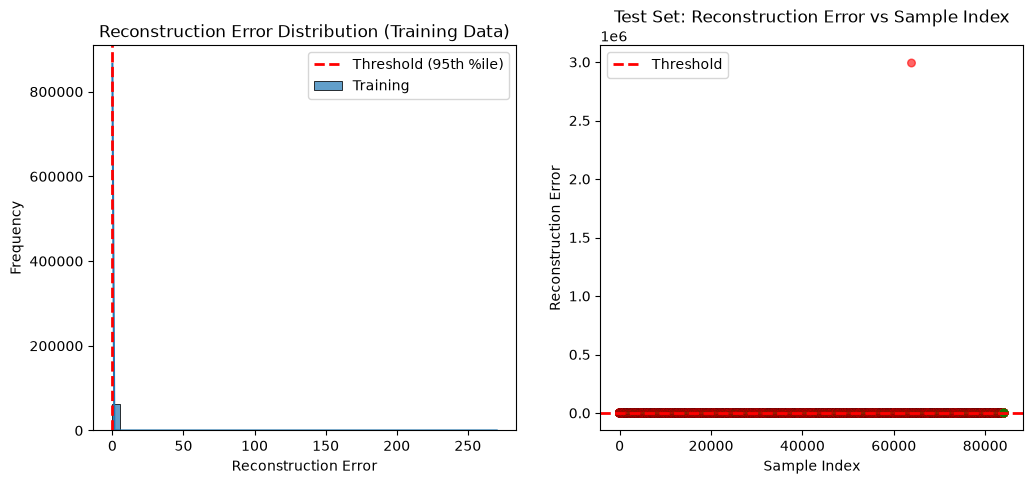

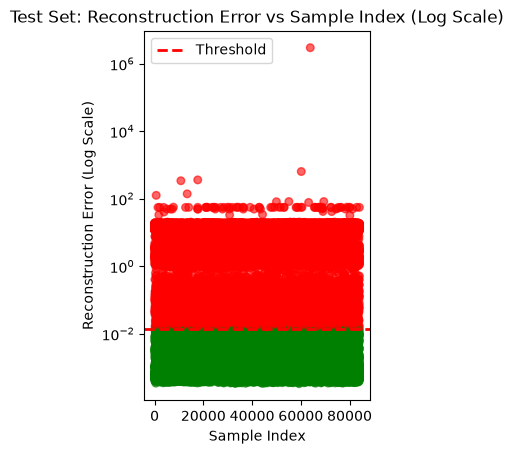

TEST SET EVALUATION METRICS
Accuracy: 0.9797

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     26350
           1       0.98      0.99      0.99     57754

    accuracy                           0.98     84104
   macro avg       0.98      0.97      0.98     84104
weighted avg       0.98      0.98      0.98     84104

Confusion Matrix:
[[25020  1330]
 [  381 57373]]


In [ ]:
# Check if the final model has been trained in the notebook, if not load the best model from disk
if not 'final_model' in locals() or final_model is None:
    print("Final model not found. Loading the best model from model directory...")
    final_model = keras.models.load_model(models_dir / "autoencoder_model_best_v2.keras")
else:
    print("A new final model has been trained in the notebook.")

# Output the model summary for verification
print("\nFinal Model Summary:")
final_model.summary()

print("Generating anomaly metrics and threshold...\n")
threshold, y_pred = generate_anomaly_metrics_and_threshold(final_model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE)